In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/d-08-learning-task-1/sample_submission.csv
/kaggle/input/competitions/d-08-learning-task-1/train.csv
/kaggle/input/competitions/d-08-learning-task-1/test.csv


In [2]:
!pip install matplotlib seaborn
!pip install xgboost
!pip install scikit-learn
!pip install pandas

In [3]:
import pandas as pd 
train_data= pd.read_csv('/kaggle/input/competitions/d-08-learning-task-1/train.csv')
test_data  = pd.read_csv('/kaggle/input/competitions/d-08-learning-task-1/test.csv')
train_data.head()
test_data.head()

,id,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight
0,15000,F,1.3375,1.0625,0.3875,22.424454,10.432616,5.684075,6.095142
1,15001,I,0.9250,0.7000,0.2250,6.307764,2.778251,1.063106,1.715145
2,15002,M,1.5750,1.2125,0.4125,31.708916,13.295915,7.739414,8.788345
3,15003,F,1.5625,1.2000,0.4375,38.002505,18.852418,7.711064,9.213587
4,15004,I,0.9000,0.6625,0.2375,5.556502,2.721552,1.658446,2.126212


In [4]:
train_data.describe()

,id,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.312079,1.020090,0.345784,23.124152,9.990921,5.000717,6.624265,9.920867
std,4330.271354,0.290458,0.239277,0.091209,12.649092,5.622231,2.799683,3.548370,3.189161
min,0.000000,0.187500,0.112500,0.000000,0.226796,0.070874,0.070874,0.042524,1.000000
25%,3749.750000,1.150000,0.887500,0.287500,13.083294,5.669900,2.792426,3.827183,8.000000
50%,7499.500000,1.375000,1.075000,0.362500,23.700182,9.865626,4.904464,6.803880,10.000000
75%,11249.250000,1.525000,1.200000,0.412500,32.077459,13.947954,6.959802,9.032859,11.000000
max,14999.000000,1.950000,1.575000,0.775000,78.797435,38.300174,18.512224,25.429502,29.000000


In [5]:
# Convert categorical 'Sex' column into numerical dummy columns
train_data = pd.get_dummies(train_data, columns=['Sex'], drop_first=True)
test_data = pd.get_dummies(test_data, columns=['Sex'], drop_first=True)

# Look at the data again to see the changes!
train_data.head()

,id,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age,Sex_I,Sex_M
0,0,1.3500,1.0500,0.3250,19.830475,8.830869,3.657085,6.095142,10.0,False,True
1,1,1.2875,0.9500,0.2875,18.313777,8.972617,3.869707,4.876114,9.0,True,False
2,2,1.2500,1.0000,0.4000,21.659018,7.796112,5.032036,7.087375,12.0,False,True
3,3,1.4625,1.1500,0.3750,26.818627,13.423488,5.173784,6.662133,11.0,False,True
4,4,1.1500,0.9375,0.2750,13.777857,6.038443,3.033396,4.110678,8.0,True,False


In [6]:
from sklearn.model_selection import train_test_split
x= train_data.drop(['id' , 'Age'] ,axis=1)
y=train_data['Age']
x_test=test_data.drop(['id'] ,axis=1)
x_train , x_val , y_train , y_val = train_test_split(x , y , test_size=0.1 ,random_state=42)
print(f"training features shape:{x_train.shape}")
print(f"validation features shape:{x_val.shape}")
print(f"training features shape:{y_train.shape}")

training features shape:(13500, 9)
validation features shape:(1500, 9)
training features shape:(13500,)


In [7]:
print(x_train.dtypes)        # check for object (text) columns
print(x_train.isnull().sum())  # check missing values
print(x_train.shape, y_train.shape)

Length            float64
Diameter          float64
Height            float64
Weight            float64
Shucked Weight    float64
Viscera Weight    float64
Shell Weight      float64
Sex_I                bool
Sex_M                bool
dtype: object
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
Sex_I             0
Sex_M             0
dtype: int64
(13500, 9) (13500,)


In [8]:
x_train_fe=x_train.copy()
x_val_fe=x_val.copy()
x_train_fe['Volume']=x_train_fe['Length']*x_train_fe['Diameter']*x_train_fe['Height']
x_val_fe['Volume']=x_val_fe['Length']*x_val_fe['Diameter']*x_val_fe['Height']
x_train_fe['Density']=x_train_fe['Weight']/(x_train_fe['Volume']+1e-8)
x_val_fe['Density']=x_val_fe['Weight']/(x_val_fe['Volume']+1e-8)
print("new features added ,weight and density")

new features added ,weight and density


In [9]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

xgb_model = XGBRegressor(n_estimators=1500, learning_rate=0.005, random_state=42)

print("Training XGBoost...")
xgb_model.fit(x_train_fe, y_train)

# Predict and evaluate
xgb_val_predictions = xgb_model.predict(x_val_fe)
xgb_cost = mean_absolute_error(y_val, xgb_val_predictions)

print(f"XGBoost Validation MAE: {xgb_cost:.4f}")

Training XGBoost...
XGBoost Validation MAE: 1.3813


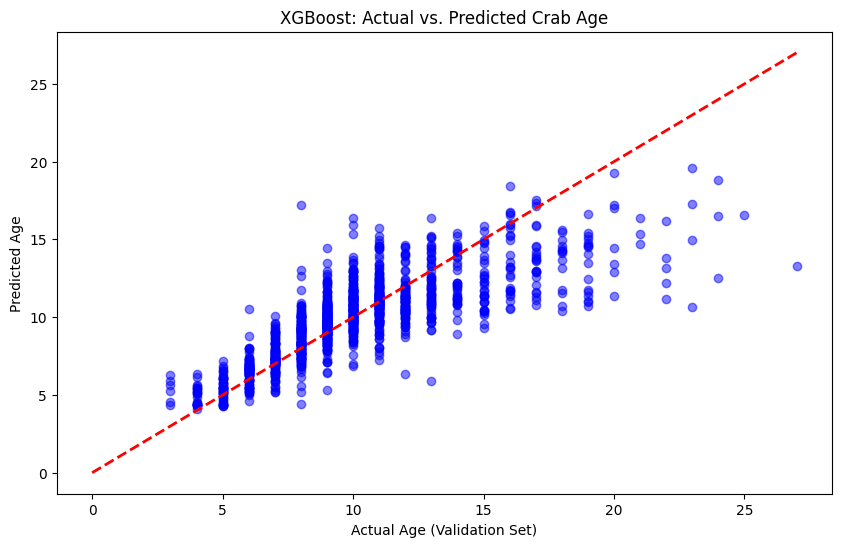

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10 , 6))
plt.scatter(y_val , xgb_val_predictions , alpha=0.5 , color = 'blue')
max_age = max(y_val.max(), xgb_val_predictions.max())
plt.plot([0 , max_age] , [0 , max_age] , color='red' , linestyle='--' , linewidth=2)
plt.title('XGBoost: Actual vs. Predicted Crab Age')
plt.xlabel('Actual Age (Validation Set)')
plt.ylabel('Predicted Age')
plt.show()

/tmp/ipykernel_17/3126334917.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


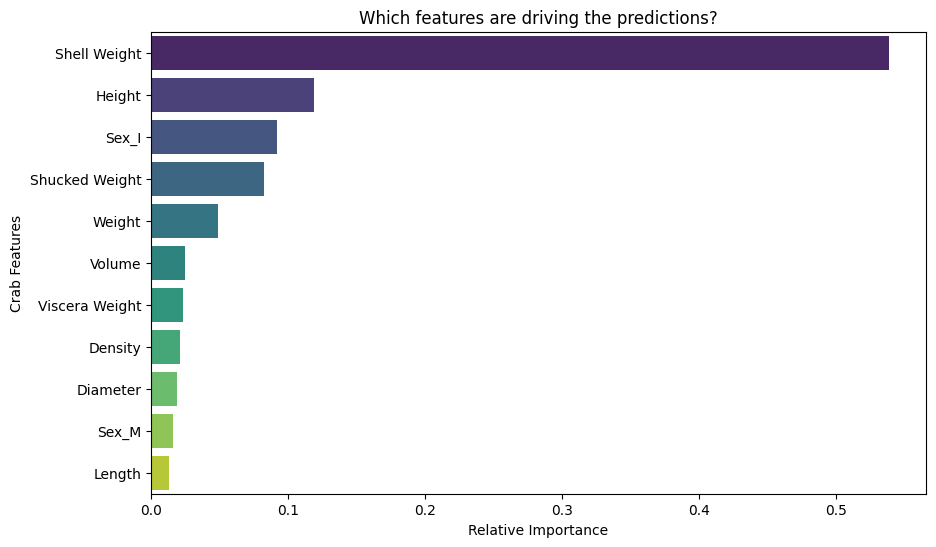

In [11]:
import pandas as pd

# Extract feature importances from the XGBoost model
importances = xgb_model.feature_importances_

# Create a DataFrame to make plotting easier
feature_names = x_train_fe.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Which features are driving the predictions?')
plt.xlabel('Relative Importance')
plt.ylabel('Crab Features')
plt.show()

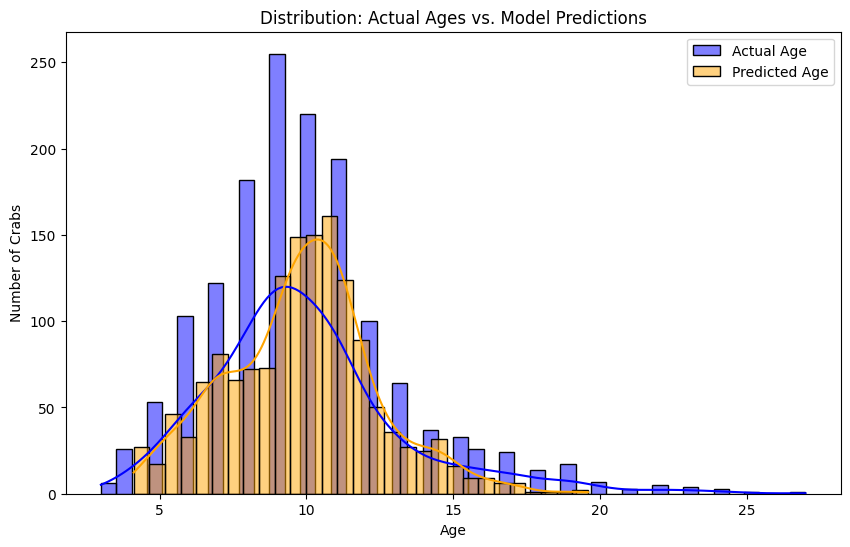

In [12]:
plt.figure(figsize=(10, 6))

# Plot the real ages in Blue
sns.histplot(y_val, color="blue", label="Actual Age", kde=True, alpha=0.5)

# Plot the predicted ages in Orange
sns.histplot(xgb_val_predictions, color="orange", label="Predicted Age", kde=True, alpha=0.5)

plt.title('Distribution: Actual Ages vs. Model Predictions')
plt.xlabel('Age')
plt.ylabel('Number of Crabs')
plt.legend()
plt.show()

In [13]:
x_test_fe=x_test.copy()
x_test_fe['Volume'] = x_test_fe['Length'] * x_test_fe['Diameter'] * x_test_fe['Height']

# Add a tiny number to prevent division by zero errors
x_test_fe['Density'] = x_test_fe['Weight'] / (x_test_fe['Volume'] + 1e-6)

print("Test data is ready for the model!")

Test data is ready for the model!


In [14]:
final_predictions = xgb_model.predict(x_test_fe)
print(final_predictions[:5])

[ 9.550182   6.4127274 11.025511  10.603253   6.939819 ]


In [15]:
# 4. Create a final DataFrame matching Kaggle's format
submission_df = pd.DataFrame({
    'id': test_data['id'],
    'Age': final_predictions
})

# 5. Save it to your current folder as a CSV file
# index=False is crucial here, otherwise Pandas adds an extra column of row numbers!
submission_df.to_csv('my_first_submission.csv', index=False)

print("my_first_submission.csv successfully created!")

my_first_submission.csv successfully created!
